# Feature Engineering

#### ___Algorithms are only as good as their data___

What is __Feature Engineering__?
- getting raw data and extracting features for machine learning
- features = data stored on the columns of table/dataset/dataframes
- goal is to make your data better suited to the problem at hand.
- you perform feature engineering to improve a model's predictive performance, reduce computational or data needs, and improve interpretability of the results
- process of transforming raw data into features that better represent the underlying problem to the predictive models, resulting in improved model accuracy on unseen data.

Read more about feature engineering in kaggle.https://www.kaggle.com/learn/feature-engineering

__How do we perform Feature Engineering__
- transforming existing features - applying techniques to standardize or normalize our data and deal with outliers that may impact our predictions.
- extracting new features from existing attributes - applying domain knowledge to add new features to our data. For example, in credit risk, we know by experience that the age of an account is a factor in the likelihood of whether this account will default or not. Therefore, we want to add this as part of our feature. To do this, we can derive the age of the account from the Account Opening Date attribute and add this new feature to our data.

__The following are the activities we do in Feature Engineering:__

- Brainstorm features – identify features that we should include in our data. This often depends on the problem that we are trying to solve or based on business requirements.
- Create features – Here we do the actual transformation and creation of features to be included in our data.
- Check how the features work with model – Some features may not be useful to our model contrary to our assumptions. We either remove these or tweak or improve them.
- Start again from the first until features work perfectly.

Types of Data
- _Numeric Data: Continuous or Quantitative, Discrete_
- _Categorical variables or Qualitative_

Scales of Measurement
- Nominal Scale (e.g. Color, Gender, Player#)
- Ordinal Scale (e.g. Clothing Size, Military Rank)
- Interval Scale (e.g. Temperature, IQ Rating)
- Ratio Scale (e.g. Height, Weight, Age)

### Explore and Analyze Data

In [34]:
import pandas as pd
pd.set_option("display.max_row",None)
pd.set_option("display.max_column",None)

In [35]:
df=pd.read_csv('dataset/titanic2.csv')
df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1.0,1.0,"Allen, Miss. Elisabeth Walton",female,29.0000,0.0,0.0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1.0,1.0,"Allison, Master. Hudson Trevor",male,0.9167,1.0,2.0,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1.0,0.0,"Allison, Miss. Helen Loraine",female,2.0000,1.0,2.0,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1.0,0.0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1.0,2.0,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1.0,0.0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1.0,2.0,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [36]:
df.shape

(1310, 14)

In [37]:
df.columns

Index(['pclass', 'survived', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket',
       'fare', 'cabin', 'embarked', 'boat', 'body', 'home.dest'],
      dtype='str')

In [38]:
df.age=df[df.age.notna()].age.astype('int')
df.isna().sum()

pclass          1
survived        1
name            1
sex             1
age           264
sibsp           1
parch           1
ticket          1
fare            2
cabin        1015
embarked        3
boat          824
body         1189
home.dest     565
dtype: int64

In [39]:
df.dtypes

pclass       float64
survived     float64
name             str
sex              str
age          float64
sibsp        float64
parch        float64
ticket           str
fare         float64
cabin            str
embarked         str
boat             str
body         float64
home.dest        str
dtype: object

##### <font color="GREEN"> _Choose only columns that are important base on the objectives of the study or data analysis._</font>

In [40]:
data=df[['pclass','sex','age','sibsp','parch','fare','embarked','boat','home.dest','survived']].copy()
data.head()

,pclass,sex,age,sibsp,parch,fare,embarked,boat,home.dest,survived
0,1.0,female,29.0,0.0,0.0,211.3375,S,2,"St Louis, MO",1.0
1,1.0,male,0.0,1.0,2.0,151.5500,S,11,"Montreal, PQ / Chesterville, ON",1.0
2,1.0,female,2.0,1.0,2.0,151.5500,S,NaN,"Montreal, PQ / Chesterville, ON",0.0
3,1.0,male,30.0,1.0,2.0,151.5500,S,NaN,"Montreal, PQ / Chesterville, ON",0.0
4,1.0,female,25.0,1.0,2.0,151.5500,S,NaN,"Montreal, PQ / Chesterville, ON",0.0


In [41]:
data.tail()

,pclass,sex,age,sibsp,parch,fare,embarked,boat,home.dest,survived
1305,3.0,female,NaN,1.0,0.0,14.4542,C,NaN,NaN,0.0
1306,3.0,male,26.0,0.0,0.0,7.2250,C,NaN,NaN,0.0
1307,3.0,male,27.0,0.0,0.0,7.2250,C,NaN,NaN,0.0
1308,3.0,male,29.0,0.0,0.0,7.8750,S,NaN,NaN,0.0
1309,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### NULL TREATMENT
##### <font color= "GREEN"> _Remove rows with less than 70% Non-NA values._ </font>

In [42]:
data.dropna(thresh=0.7*data.shape[1],inplace=True) 

In [43]:
data.tail()

,pclass,sex,age,sibsp,parch,fare,embarked,boat,home.dest,survived
1304,3.0,female,14.0,1.0,0.0,14.4542,C,NaN,NaN,0.0
1305,3.0,female,NaN,1.0,0.0,14.4542,C,NaN,NaN,0.0
1306,3.0,male,26.0,0.0,0.0,7.2250,C,NaN,NaN,0.0
1307,3.0,male,27.0,0.0,0.0,7.2250,C,NaN,NaN,0.0
1308,3.0,male,29.0,0.0,0.0,7.8750,S,NaN,NaN,0.0


In [44]:
data.shape

(1309, 10)

In [45]:
data.dtypes

pclass       float64
sex              str
age          float64
sibsp        float64
parch        float64
fare         float64
embarked         str
boat             str
home.dest        str
survived     float64
dtype: object

#### <font color=GREEN> _Check other null values_ </FONT>

In [46]:
data.isna().sum()

pclass         0
sex            0
age          263
sibsp          0
parch          0
fare           1
embarked       2
boat         823
home.dest    564
survived       0
dtype: int64

In [47]:
data[data.fare.isna() | data.embarked.isna()]

,pclass,sex,age,sibsp,parch,fare,embarked,boat,home.dest,survived
168,1.0,female,38.0,0.0,0.0,80.0,NaN,6,NaN,1.0
284,1.0,female,62.0,0.0,0.0,80.0,NaN,6,"Cincinatti, OH",1.0
1225,3.0,male,60.0,0.0,0.0,NaN,S,NaN,NaN,0.0


In [48]:
data[(data.pclass==3.0) & (data.sibsp==0) & (data.parch==0) & (data.age>=50)].sort_values(by=['age','fare'])

,pclass,sex,age,sibsp,parch,fare,embarked,boat,home.dest,survived
1160,3.0,male,50.0,0.0,0.0,8.0500,S,NaN,NaN,0.0
979,3.0,male,51.0,0.0,0.0,7.0542,S,NaN,NaN,0.0
1287,3.0,male,51.0,0.0,0.0,7.7500,S,NaN,NaN,0.0
833,3.0,male,51.0,0.0,0.0,8.0500,S,NaN,"Dorking, Surrey, England",0.0
1015,3.0,male,55.0,0.0,0.0,8.0500,S,NaN,NaN,0.0
736,3.0,male,59.0,0.0,0.0,7.2500,S,NaN,"Merrill, WI",0.0
1225,3.0,male,60.0,0.0,0.0,NaN,S,NaN,NaN,0.0
1068,3.0,male,61.0,0.0,0.0,6.2375,S,NaN,NaN,0.0
1261,3.0,female,63.0,0.0,0.0,9.5875,S,15,NaN,1.0
782,3.0,male,65.0,0.0,0.0,7.7500,Q,NaN,NaN,0.0


In [49]:
# Use median value to impute missing values on fare column
med_fare=data[(data.sibsp==0) & (data.parch==0) & (data.age>=50) & (data.pclass==3.0)].fare.median()
data.fare.fillna(med_fare,inplace=True)

C:\Users\ALi\AppData\Local\Temp\ipykernel_4544\338799284.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data.fare.fillna(med_fare,inplace=True)


0       211.3375
1       151.5500
2       151.5500
3       151.5500
4       151.5500
5        26.5500
6        77.9583
7         0.0000
8        51.4792
9        49.5042
10      227.5250
11      227.5250
12       69.3000
13       78.8500
14       30.0000
15       25.9250
16      247.5208
17      247.5208
18       76.2917
19       75.2417
20       52.5542
21       52.5542
22       30.0000
23      227.5250
24      221.7792
25       26.0000
26       91.0792
27       91.0792
28      135.6333
29       26.5500
30       35.5000
31       31.0000
32      164.8667
33       26.5500
34       26.5500
35      262.3750
36       55.0000
37       26.5500
38       30.5000
39       50.4958
40       39.6000
41       27.7208
42       51.4792
43       76.2917
44      134.5000
45       26.5500
46       31.0000
47       26.2875
48       27.4458
49      512.3292
50      512.3292
51        5.0000
52       47.1000
53       47.1000
54      120.0000
55      120.0000
56      120.0000
57      120.0000
58       26.00

In [50]:
data.isna().sum()

pclass         0
sex            0
age          263
sibsp          0
parch          0
fare           1
embarked       2
boat         823
home.dest    564
survived       0
dtype: int64

In [51]:
#Use 'X' to replace missing values on embarked
data.embarked.fillna('X',inplace=True)

C:\Users\ALi\AppData\Local\Temp\ipykernel_4544\1079004061.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data.embarked.fillna('X',inplace=True)


0       S
1       S
2       S
3       S
4       S
5       S
6       S
7       S
8       S
9       C
10      C
11      C
12      C
13      S
14      S
15      S
16      C
17      C
18      C
19      C
20      S
21      S
22      C
23      C
24      S
25      C
26      C
27      C
28      S
29      S
30      S
31      C
32      S
33      S
34      S
35      C
36      S
37      S
38      S
39      C
40      C
41      C
42      S
43      C
44      C
45      S
46      S
47      S
48      C
49      C
50      C
51      S
52      S
53      S
54      S
55      S
56      S
57      S
58      S
59      C
60      S
61      S
62      S
63      S
64      S
65      S
66      C
67      S
68      C
69      S
70      S
71      C
72      C
73      S
74      S
75      S
76      C
77      C
78      C
79      S
80      S
81      S
82      S
83      S
84      C
85      C
86      S
87      S
88      S
89      S
90      S
91      S
92      S
93      S
94      S
95      S
96      C
97      C
98      C
99      C


In [52]:
print(data.age.max())
print(data[data.age.isna()])
# Capping: Use max+10, the max value for age to replace all missing values for age
data.age.fillna(data.age.max()+10,inplace=True)

C:\Users\ALi\AppData\Local\Temp\ipykernel_4544\2467390538.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data.age.fillna(data.age.max()+10,inplace=True)


80.0
      pclass     sex  age  sibsp  parch      fare embarked   boat  \
15       1.0    male  NaN    0.0    0.0   25.9250        S    NaN   
37       1.0    male  NaN    0.0    0.0   26.5500        S      9   
40       1.0    male  NaN    0.0    0.0   39.6000        C    NaN   
46       1.0    male  NaN    0.0    0.0   31.0000        S    NaN   
59       1.0  female  NaN    0.0    0.0   27.7208        C      5   
69       1.0  female  NaN    0.0    1.0   55.0000        S      6   
70       1.0    male  NaN    0.0    0.0    0.0000        S    NaN   
74       1.0    male  NaN    0.0    0.0   52.0000        S    NaN   
80       1.0    male  NaN    0.0    0.0   26.5500        S    NaN   
106      1.0    male  NaN    0.0    0.0  221.7792        S    NaN   
107      1.0  female  NaN    0.0    0.0   31.6833        S      7   
108      1.0  female  NaN    0.0    0.0  110.8833        C      4   
118      1.0    male  NaN    0.0    0.0   26.5500        S    NaN   
121      1.0  female  NaN    

0       29.0
1        0.0
2        2.0
3       30.0
4       25.0
5       48.0
6       63.0
7       39.0
8       53.0
9       71.0
10      47.0
11      18.0
12      24.0
13      26.0
14      80.0
15      90.0
16      24.0
17      50.0
18      32.0
19      36.0
20      37.0
21      47.0
22      26.0
23      42.0
24      29.0
25      25.0
26      25.0
27      19.0
28      35.0
29      28.0
30      45.0
31      40.0
32      30.0
33      58.0
34      42.0
35      45.0
36      22.0
37      90.0
38      41.0
39      48.0
40      90.0
41      44.0
42      59.0
43      60.0
44      41.0
45      45.0
46      90.0
47      42.0
48      53.0
49      36.0
50      58.0
51      33.0
52      28.0
53      17.0
54      11.0
55      14.0
56      36.0
57      36.0
58      49.0
59      90.0
60      36.0
61      76.0
62      46.0
63      47.0
64      27.0
65      33.0
66      36.0
67      30.0
68      45.0
69      90.0
70      90.0
71      27.0
72      26.0
73      22.0
74      90.0
75      47.0
76      39.0

In [53]:
data.isna().sum()

pclass         0
sex            0
age          263
sibsp          0
parch          0
fare           1
embarked       2
boat         823
home.dest    564
survived       0
dtype: int64

In [54]:
data[data.boat.notna() & (data.survived==0)]

,pclass,sex,age,sibsp,parch,fare,embarked,boat,home.dest,survived
19,1.0,male,36.0,0.0,0.0,75.2417,C,A,"Winnipeg, MN",0.0
166,1.0,male,NaN,0.0,0.0,30.6958,C,14,"New York, NY",0.0
544,2.0,male,34.0,1.0,0.0,21.0000,S,12,"Elizabeth, NJ",0.0
655,3.0,male,32.0,1.0,0.0,15.8500,S,D,"Ruotsinphytaa, Finland New York, NY",0.0
853,3.0,male,25.0,0.0,0.0,7.2500,S,B,NaN,0.0
921,3.0,male,NaN,0.0,0.0,7.2500,S,A,NaN,0.0
968,3.0,male,36.0,1.0,0.0,15.5500,S,A,NaN,0.0
969,3.0,female,30.0,1.0,0.0,15.5500,S,A,NaN,0.0
1299,3.0,male,27.0,1.0,0.0,14.4542,C,C,NaN,0.0


In [55]:
data[data.boat.isna() & (data.survived==1)]

,pclass,sex,age,sibsp,parch,fare,embarked,boat,home.dest,survived
192,1.0,female,58.0,0.0,0.0,146.5208,C,NaN,NaN,1.0
358,2.0,female,42.0,0.0,0.0,13.0000,S,NaN,"New York, NY",1.0
395,2.0,female,18.0,0.0,1.0,23.0000,S,NaN,Southampton,1.0
396,2.0,female,34.0,0.0,1.0,23.0000,S,NaN,Southampton,1.0
458,2.0,female,17.0,0.0,0.0,10.5000,S,NaN,Guernsey,1.0
489,2.0,female,42.0,1.0,0.0,26.0000,S,NaN,"Weston-Super-Mare, Somerset",1.0
513,2.0,female,14.0,1.0,0.0,30.0708,C,NaN,"New York, NY",1.0
545,2.0,female,30.0,3.0,0.0,21.0000,S,NaN,"Elizabeth, NJ",1.0
572,2.0,female,28.0,0.0,0.0,12.6500,S,NaN,"Columbus, OH",1.0
656,3.0,female,33.0,3.0,0.0,15.8500,S,NaN,"Ruotsinphytaa, Finland New York, NY",1.0


In [56]:
#Create a separate category "No Boat Number" for NAN on boat
data.loc[data.boat.isna() & (data.survived==1),'boat']="No Boat Number"
data.loc[data.boat.isna() & (data.survived==0),'boat']="Body Not Found"

In [57]:
emb_data=data.groupby(by=['embarked']).describe(include="object")
emb_data

C:\Users\ALi\AppData\Local\Temp\ipykernel_4544\466113229.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  emb_data=data.groupby(by=['embarked']).describe(include="object")
C:\Users\ALi\AppData\Local\Temp\ipykernel_4544\466113229.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_gui

sex                    boat                             home.dest  \
         count unique   top freq count unique             top freq     count   
embarked                                                                       
C          270      2  male  157   270     22  Body Not Found  117       172   
Q          123      2  male   63   123     12  Body Not Found   79        37   
S          914      2  male  623   914     27  Body Not Found  604       535   

                                           
         unique                  top freq  
embarked                                   
C            70         New York, NY   33  
Q            25  Ireland Chicago, IL    4  
S           293         New York, NY   29

In [58]:
emb_data['home.dest'].top

embarked
C           New York, NY
Q    Ireland Chicago, IL
S           New York, NY
Name: top, dtype: object

In [59]:
# Use the mode of the home.dest per embarkation
data.loc[(data.embarked=='C') & (data['home.dest'].isna()),'home.dest']= 'New York, NY'
data.loc[(data.embarked=='Q') & (data['home.dest'].isna()),'home.dest']= 'Ireland Chicago, IL'
data.loc[(data.embarked=='S') & (data['home.dest'].isna()),'home.dest']= 'New York, NY'
data.loc[(data.embarked=='X') & (data['home.dest'].isna()),'home.dest']= 'Cincinatti, OH'

In [60]:
data.isna().sum()

pclass         0
sex            0
age          263
sibsp          0
parch          0
fare           1
embarked       2
boat           0
home.dest      1
survived       0
dtype: int64

In [61]:
data.age=data.age.astype('float')
data.pclass=data.pclass.astype('int')
data.sibsp=data.sibsp.astype('int')
data.parch=data.parch.astype('int')
data.survived=data.survived.astype('int')
data.dtypes

pclass         int64
sex              str
age          float64
sibsp          int64
parch          int64
fare         float64
embarked         str
boat             str
home.dest        str
survived       int64
dtype: object

### Visualize Data to detect outliers

In [62]:
import matplotlib.pyplot as plt
import seaborn as sn
import plotly.express as px

In [63]:
fig=px.scatter(data,x='age',y='sex',color='survived',hover_data=['pclass','fare','embarked'])
fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

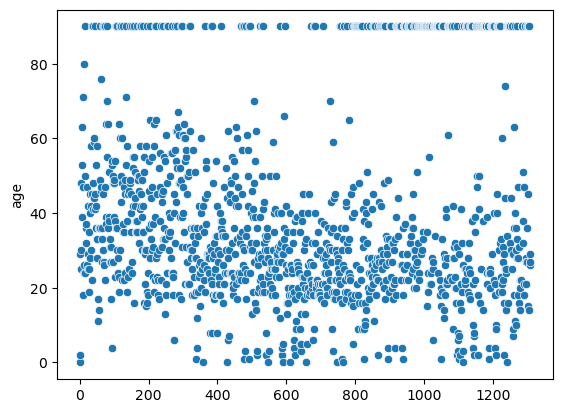

In [ ]:
sn.scatterplot(data.age)
plt.show()

<AxesSubplot: >

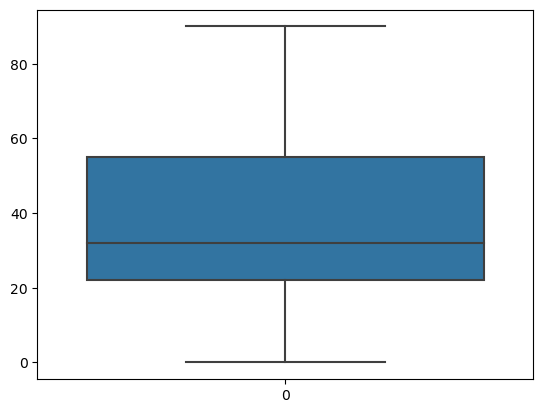

In [ ]:
sn.boxplot(data.age)

In [ ]:
px.histogram(data.age)

In [ ]:
import math
bin_width= 2
nbins = math.ceil((data[data.age<90].age.max() - data[data.age<90].age.min()) / bin_width)
fig = px.histogram(data[data.age<90], x="age", nbins=nbins)
fig.show()

In [ ]:
import scipy

In [ ]:
scipy.stats.shapiro(data[data.age<90].age)


ShapiroResult(statistic=0.979983389377594, pvalue=8.165188664088774e-11)

In [ ]:
data[data.age<90].age.skew()

0.40190872498615504

In [ ]:
#interquartile range method
import numpy as np
IQR=np.percentile(data[data.age<90].age, 75)-np.percentile(data[data.age<90].age, 25)
lower=max(0,np.percentile(data[data.age<90].age, 25)-1.5*IQR)
upper=np.percentile(data[data.age<90].age, 75)+1.5*IQR
print("Range is from", lower," to ", upper)
print(data[data.age<90].age.mean())

Range is from 0  to  66.0
29.85755258126195


In [ ]:
data[(data.age<lower) | (data.age>upper)].shape #ouliers

(272, 10)

In [ ]:
data.loc[(data.age!=90) & ((data.age<lower) | (data.age>upper)),"age"]=data.age.median() #imputation

In [ ]:
data[(data.age<lower) | (data.age>upper)] #ouliers

,pclass,sex,age,sibsp,parch,fare,embarked,boat,home.dest,survived
15,1,male,90,0,0,25.9250,S,Body Not Found,"New York, NY",0
37,1,male,90,0,0,26.5500,S,9,"Los Angeles, CA",1
40,1,male,90,0,0,39.6000,C,Body Not Found,"Philadelphia, PA",0
46,1,male,90,0,0,31.0000,S,Body Not Found,"New York, NY",0
59,1,female,90,0,0,27.7208,C,5,"New York, NY",1
69,1,female,90,0,1,55.0000,S,6,"St Leonards-on-Sea, England Ohio",1
70,1,male,90,0,0,0.0000,S,Body Not Found,"Liverpool, England / Belfast",0
74,1,male,90,0,0,52.0000,S,Body Not Found,"Stoughton, MA",0
80,1,male,90,0,0,26.5500,S,Body Not Found,"Roachdale, IN",0
106,1,male,90,0,0,221.7792,S,Body Not Found,"New York, NY",0


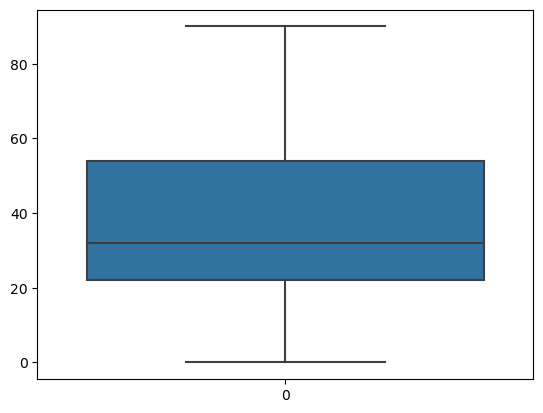

In [ ]:
sn.boxplot(data.age)
plt.show()

In [ ]:
px.histogram(data.age)

In [ ]:
px.histogram(data.fare)

In [ ]:
data.fare.skew()

4.369195355150415

In [ ]:
scipy.stats.shapiro(data.fare)

ShapiroResult(statistic=0.527653694152832, pvalue=0.0)

## Handling Categorical Data

### 1. One-Hot Encoding vs Dummy Encoding : Converts N-categories into N-Features

In [ ]:
import sys
sys.setrecursionlimit(1500)

In [ ]:
data_with_OHE = pd.get_dummies(data,columns=['sex','embarked'])
data_with_OHE.columns

Index(['pclass', 'age', 'sibsp', 'parch', 'fare', 'boat', 'home.dest',
       'survived', 'sex_female', 'sex_male', 'embarked_C', 'embarked_Q',
       'embarked_S', 'embarked_X'],
      dtype='object')

In [ ]:
data_with_OHE.head()

,pclass,age,sibsp,parch,fare,boat,home.dest,survived,sex_female,sex_male,embarked_C,embarked_Q,embarked_S,embarked_X
0,1,29,0,0,211.3375,2,"St Louis, MO",1,1,0,0,0,1,0
1,1,0,1,2,151.5500,11,"Montreal, PQ / Chesterville, ON",1,0,1,0,0,1,0
2,1,2,1,2,151.5500,Body Not Found,"Montreal, PQ / Chesterville, ON",0,1,0,0,0,1,0
3,1,30,1,2,151.5500,Body Not Found,"Montreal, PQ / Chesterville, ON",0,0,1,0,0,1,0
4,1,25,1,2,151.5500,Body Not Found,"Montreal, PQ / Chesterville, ON",0,1,0,0,0,1,0


In [ ]:
data_with_OHE.shape

(1309, 14)

In [ ]:
data.shape

(1309, 10)

In [ ]:
data_with_OHE[['sex_female', 'sex_male', 'embarked_C',
       'embarked_Q', 'embarked_S','embarked_X']].tail(5)

,sex_female,sex_male,embarked_C,embarked_Q,embarked_S,embarked_X
1304,1,0,1,0,0,0
1305,1,0,1,0,0,0
1306,0,1,1,0,0,0
1307,0,1,1,0,0,0
1308,0,1,0,0,1,0


In [ ]:
data_with_OHE[['sex_female', 'sex_male', 'embarked_C',
       'embarked_Q', 'embarked_S','embarked_X']]

,sex_female,sex_male,embarked_C,embarked_Q,embarked_S,embarked_X
0,1,0,0,0,1,0
1,0,1,0,0,1,0
2,1,0,0,0,1,0
3,0,1,0,0,1,0
4,1,0,0,0,1,0
5,0,1,0,0,1,0
6,1,0,0,0,1,0
7,0,1,0,0,1,0
8,1,0,0,0,1,0
9,0,1,1,0,0,0


In [ ]:
data_with_dummies = pd.get_dummies(data,columns=['sex','embarked'],drop_first=True)
data_with_dummies.tail(5)

,pclass,age,sibsp,parch,fare,boat,home.dest,survived,sex_male,embarked_Q,embarked_S,embarked_X
1304,3,14,1,0,14.4542,Body Not Found,"New York, NY",0,0,0,0,0
1305,3,90,1,0,14.4542,Body Not Found,"New York, NY",0,0,0,0,0
1306,3,26,0,0,7.2250,Body Not Found,"New York, NY",0,1,0,0,0
1307,3,27,0,0,7.2250,Body Not Found,"New York, NY",0,1,0,0,0
1308,3,29,0,0,7.8750,Body Not Found,"New York, NY",0,1,0,1,0


### Using scikit-learn OneHotEncoder

In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
one=OneHotEncoder(sparse=False)

In [ ]:
one_=one.fit_transform(data[['embarked']])

In [ ]:
type(one_)

numpy.ndarray

In [ ]:
one_[:10,:]

array([[0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [1., 0., 0., 0.]])

In [ ]:
data['emb_C']=one_[:,0]

In [ ]:
data['emb_Q']=one_[:,1]

In [ ]:
data['emb_S']=one.fit_transform(data[['embarked']])[:,2]

In [ ]:
data[['embarked','emb_C','emb_Q','emb_S']].tail(10)

,embarked,emb_C,emb_Q,emb_S
1299,C,1.0,0.0,0.0
1300,C,1.0,0.0,0.0
1301,C,1.0,0.0,0.0
1302,C,1.0,0.0,0.0
1303,C,1.0,0.0,0.0
1304,C,1.0,0.0,0.0
1305,C,1.0,0.0,0.0
1306,C,1.0,0.0,0.0
1307,C,1.0,0.0,0.0
1308,S,0.0,0.0,1.0


In [ ]:
data['male']=one.fit_transform(data[['sex']])[:,1]
data.head()

,pclass,sex,age,sibsp,parch,fare,embarked,boat,home.dest,survived,emb_C,emb_Q,emb_S,male
0,1,female,29,0,0,211.3375,S,2,"St Louis, MO",1,0.0,0.0,1.0,0.0
1,1,male,0,1,2,151.5500,S,11,"Montreal, PQ / Chesterville, ON",1,0.0,0.0,1.0,1.0
2,1,female,2,1,2,151.5500,S,Body Not Found,"Montreal, PQ / Chesterville, ON",0,0.0,0.0,1.0,0.0
3,1,male,30,1,2,151.5500,S,Body Not Found,"Montreal, PQ / Chesterville, ON",0,0.0,0.0,1.0,1.0
4,1,female,25,1,2,151.5500,S,Body Not Found,"Montreal, PQ / Chesterville, ON",0,0.0,0.0,1.0,0.0


### 2. Label Encoding : converts each value in a column to a number.

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
data.embarked.unique()

array(['S', 'C', 'X', 'Q'], dtype=object)

In [ ]:
lbl=LabelEncoder()
lbl.fit_transform(data['embarked'])

array([2, 2, 2, ..., 0, 0, 2])

In [ ]:
data['embarked'].values

array(['S', 'S', 'S', ..., 'C', 'C', 'S'], dtype=object)

In [ ]:
data['emb_label']=lbl.fit_transform(data['embarked'])
data.head()

,pclass,sex,age,sibsp,parch,fare,embarked,boat,home.dest,survived,emb_C,emb_Q,emb_S,male,emb_label
0,1,female,29,0,0,211.3375,S,2,"St Louis, MO",1,0.0,0.0,1.0,0.0,2
1,1,male,0,1,2,151.5500,S,11,"Montreal, PQ / Chesterville, ON",1,0.0,0.0,1.0,1.0,2
2,1,female,2,1,2,151.5500,S,Body Not Found,"Montreal, PQ / Chesterville, ON",0,0.0,0.0,1.0,0.0,2
3,1,male,30,1,2,151.5500,S,Body Not Found,"Montreal, PQ / Chesterville, ON",0,0.0,0.0,1.0,1.0,2
4,1,female,25,1,2,151.5500,S,Body Not Found,"Montreal, PQ / Chesterville, ON",0,0.0,0.0,1.0,0.0,2


In [ ]:
data[(data.embarked=='Q') | (data.embarked=='X')]

,pclass,sex,age,sibsp,parch,fare,embarked,boat,home.dest,survived,emb_C,emb_Q,emb_S,male,emb_label
168,1,female,38,0,0,80.0000,X,6,"Cincinatti, OH",1,0.0,0.0,0.0,0.0,3
206,1,male,44,2,0,90.0000,Q,Body Not Found,"Fond du Lac, WI",0,0.0,1.0,0.0,1.0,1
207,1,female,33,1,0,90.0000,Q,14,"Green Bay, WI",1,0.0,1.0,0.0,0.0,1
208,1,female,37,1,0,90.0000,Q,14,"Fond du Lac, WI",1,0.0,1.0,0.0,0.0,1
284,1,female,62,0,0,80.0000,X,6,"Cincinatti, OH",1,0.0,0.0,0.0,0.0,3
469,2,female,90,0,0,12.3500,Q,10,"Harrisburg, PA",1,0.0,1.0,0.0,0.0,1
470,2,male,35,0,0,12.3500,Q,Body Not Found,"Ireland Chicago, IL",0,0.0,1.0,0.0,1.0,1
472,2,male,57,0,0,12.3500,Q,Body Not Found,"Glasgow / Bangor, ME",0,0.0,1.0,0.0,1.0,1
477,2,male,90,0,0,10.7083,Q,Body Not Found,"Ireland Chicago, IL",0,0.0,1.0,0.0,1.0,1
487,2,male,61,0,0,12.3500,Q,Body Not Found,"Ireland Chicago, IL",0,0.0,1.0,0.0,1.0,1


### 3. Frequency Encoding - convert categories into frequencies¶

In [ ]:
# size of each category
print('shape of dataset:',data.shape)
encoding = data.groupby('embarked').size()
print('No. of records per embarkation:',encoding)
# get frequency of each category
encoding = encoding/len(data)
print('Frequency code of each categorgy:',encoding)
data['emb__freq_enc'] = data.embarked.map(encoding)
data.sample(5)

shape of dataset: (1309, 15)
No. of records per embarkation: embarked
C    270
Q    123
S    914
X      2
dtype: int64
Frequency code of each categorgy: embarked
C    0.206264
Q    0.093965
S    0.698243
X    0.001528
dtype: float64


,pclass,sex,age,sibsp,parch,fare,embarked,boat,home.dest,survived,emb_C,emb_Q,emb_S,male,emb_label,emb__freq_enc
312,1,male,50,1,1,211.500,C,Body Not Found,"Elkins Park, PA",0,1.0,0.0,0.0,1.0,0,0.206264
975,3,female,26,1,0,16.100,S,Body Not Found,"New York, NY",0,0.0,0.0,1.0,0.0,2,0.698243
1168,3,male,90,0,0,7.575,S,Body Not Found,"New York, NY",0,0.0,0.0,1.0,1.0,2,0.698243
1301,3,male,45,0,0,7.225,C,Body Not Found,"New York, NY",0,1.0,0.0,0.0,1.0,0,0.206264
313,1,male,27,0,2,211.500,C,Body Not Found,"Elkins Park, PA",0,1.0,0.0,0.0,1.0,0,0.206264


### 4. Target or Mean Encoding :  
 - calculate the mean of the target variable for each category and replace the category variable with the mean value. 
 - problem of overfitting

In [ ]:
data[['embarked','survived']].head()

,embarked,survived
0,S,1
1,S,1
2,S,0
3,S,0
4,S,0


In [ ]:
pd.crosstab(index=data.survived,columns=data.embarked)

embarked,C,Q,S,X
survived,,,,
0,120,79,610,0
1,150,44,304,2


In [ ]:
means=data.groupby('embarked')['survived'].mean()
means

embarked
C    0.555556
Q    0.357724
S    0.332604
X    1.000000
Name: survived, dtype: float64

In [ ]:
data['emb_mean_enc']=data['embarked'].map(means)
data.head()

### 5. Ordinal Encoding - If order matters

In [ ]:
grade={'age':[18,16,17,18,20,17,19,20,22,21,19,18,18,16,18],
       'sex':['M','F','F','F','M','M','F','M','M','F','F','F','M','M','F'],
    'grade':['A','B','A-','C','B+','A+','A','B-','B','C-','B-','C+','B+','B','B+']}
gdata=pd.DataFrame(grade)
gdata

,age,sex,grade
0,18,M,A
1,16,F,B
2,17,F,A-
3,18,F,C
4,20,M,B+
5,17,M,A+
6,19,F,A
7,20,M,B-
8,22,M,B
9,21,F,C-


In [ ]:
gdata.grade.value_counts().sort_index()

A     2
A+    1
A-    1
B     3
B+    3
B-    2
C     1
C+    1
C-    1
Name: grade, dtype: int64

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

In [ ]:
cat=['A+','A','A-','B+','B','B-','C+','C','C-']
cat.reverse()
cat

['C-', 'C', 'C+', 'B-', 'B', 'B+', 'A-', 'A', 'A+']

In [ ]:
encoder=OrdinalEncoder(categories=[cat])
encoder.fit_transform(gdata[['grade']])

array([[7.],
       [4.],
       [6.],
       [1.],
       [5.],
       [8.],
       [7.],
       [3.],
       [4.],
       [0.],
       [3.],
       [2.],
       [5.],
       [4.],
       [5.]])

In [ ]:
gdata

,age,sex,grade
0,18,M,A
1,16,F,B
2,17,F,A-
3,18,F,C
4,20,M,B+
5,17,M,A+
6,19,F,A
7,20,M,B-
8,22,M,B
9,21,F,C-


In [ ]:
gdata['num_grade']=encoder.fit_transform(gdata[['grade']])

In [ ]:
gdata

,age,sex,grade,num_grade
0,18,M,A,7.0
1,16,F,B,4.0
2,17,F,A-,6.0
3,18,F,C,1.0
4,20,M,B+,5.0
5,17,M,A+,8.0
6,19,F,A,7.0
7,20,M,B-,3.0
8,22,M,B,4.0
9,21,F,C-,0.0


In [ ]:
cat_map={'A+':1.0,'A':1.25,'A-':1.5,'B+':2,'B':2.5,'B-':3.0,'C+':3.5,'C':4,'C-':4.5}

In [ ]:
gdata['grade_point']=gdata['grade'].map(cat_map)

In [ ]:
gdata

,age,sex,grade,num_grade,grade_point
0,18,M,A,7.0,1.25
1,16,F,B,4.0,2.50
2,17,F,A-,6.0,1.50
3,18,F,C,1.0,4.00
4,20,M,B+,5.0,2.00
5,17,M,A+,8.0,1.00
6,19,F,A,7.0,1.25
7,20,M,B-,3.0,3.00
8,22,M,B,4.0,2.50
9,21,F,C-,0.0,4.50


In [ ]:
data.head()

### Standardization and Normalization of Data

__Standardization__ involves transforming the data such that it will have a mean of 0 and a standard deviation of 1.

formula: Xnew = (Xold - Mean)/(Standard Deviation)

In [ ]:
import pandas as pd
import numpy as np

nwdata=pd.read_csv('datasets/networth.csv')
nwdata.head()

,first_name,age,net_worth,height
0,Kennedy,29,1300000,160.4
1,Roanna,55,2300000,156.1
2,Kim,73,650000,151.1
3,Madeline,36,450000,162.9
4,Brody,30,1650000,153.0


In [ ]:
print('Mean')
print(nwdata.age.mean())
print(nwdata.net_worth.mean())
print(nwdata.height.mean())
print('\nStandard deviations')
print(nwdata.age.std())
print(nwdata.net_worth.std())
print(nwdata.height.std())

Mean
37.67567567567568
1718918.9189189188
159.20810810810815

Standard deviations
13.283352266933502
1158564.2066890472
6.288586591700977


In [ ]:
nwdata['std_networth'] = (nwdata.net_worth - np.mean(nwdata.net_worth))/(np.std(nwdata.net_worth))
nwdata['std_age']= (nwdata.age - np.mean(nwdata.age))/(np.std(nwdata.age))
nwdata['std_height']= (nwdata.height - np.mean(nwdata.height))/(np.std(nwdata.height))
nwdata.sample(10)

,first_name,age,net_worth,height,std_networth,std_age,std_height
34,Tatyana,37,1700000,152.1,-0.016555,-0.051568,-1.145910
5,Piper,52,2400000,156.7,0.595975,1.093241,-0.404336
25,Daquan,27,850000,164.3,-0.760342,-0.814774,0.820873
7,Ignacia,55,2200000,171.2,0.420967,1.322203,1.933233
8,Benedict,42,1650000,160.7,-0.060307,0.330035,0.240510
12,Fulton,47,2100000,167.5,0.333462,0.711638,1.336750
6,Brent,26,1600000,153.8,-0.104059,-0.891095,-0.871850
19,Ralph,20,7500000,161.1,5.058696,-1.349019,0.304995
33,Kylee,53,2500000,153.3,0.683480,1.169562,-0.952456
13,Jane,52,2150000,150.8,0.377215,1.093241,-1.355485


In [ ]:
print('Mean ',nwdata['std_height'].mean())#-0.000000000000006457

print('Std ', nwdata.std_height.std()) 

print(nwdata['std_age'].mean())
print(nwdata.std_age.std()) 

nwdata['net_worth'].head().values

nwdata[['net_worth']].head().values

Mean  -6.457297159441451e-15
Std  1.0137937550497034
-3.863276065418619e-17
1.0137937550497034


array([[1300000],
       [2300000],
       [ 650000],
       [ 450000],
       [1650000]], dtype=int64)

In [ ]:
from sklearn.preprocessing import StandardScaler
st_scaler=StandardScaler()
nwdata['st_scaled_networth']=st_scaler.fit_transform(nwdata[['net_worth']])
nwdata['st_scaled_age']=st_scaler.fit_transform(nwdata[['age']])
nwdata['st_scaled_height']=st_scaler.fit_transform(nwdata[['height']])
nwdata.head()

,first_name,age,net_worth,height,std_networth,std_age,std_height,st_scaled_networth,st_scaled_age,st_scaled_height
0,Kennedy,29,1300000,160.4,-0.366572,-0.662133,0.192147,-0.366572,-0.662133,0.192147
1,Roanna,55,2300000,156.1,0.508471,1.322203,-0.501063,0.508471,1.322203,-0.501063
2,Kim,73,650000,151.1,-0.935350,2.695975,-1.307122,-0.935350,2.695975,-1.307122
3,Madeline,36,450000,162.9,-1.110359,-0.127889,0.595176,-1.110359,-0.127889,0.595176
4,Brody,30,1650000,153.0,-0.060307,-0.585812,-1.000820,-0.060307,-0.585812,-1.000820


__Normalization__ can be achieved using the Min-Max Scaling that will scale the numeric values in the range of 0 to 1.

Formula:
Xnormalized=(X-Xmin)/(Xmax-Xmin)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

minmax=MinMaxScaler()
nwdata['minmax_scaled_networth']=minmax.fit_transform(nwdata[['net_worth']])
nwdata[['net_worth','st_scaled_networth','minmax_scaled_networth']]

,net_worth,st_scaled_networth,minmax_scaled_networth
0,1300000,-0.366572,0.120567
1,2300000,0.508471,0.262411
2,650000,-0.935350,0.028369
3,450000,-1.110359,0.000000
4,1650000,-0.060307,0.170213
5,2400000,0.595975,0.276596
6,1600000,-0.104059,0.163121
7,2200000,0.420967,0.248227
8,1650000,-0.060307,0.170213
9,1050000,-0.585333,0.085106


## Try this
<ol>
    <li>Drop the columns sex and embarked.</li>
    <li>Drop all encodings for embarked except the frequency encoding column. </li>
    <li>Apply frequency encoding for boat and home.dest columns.</li>
    <li>Apply either standardization or normalization on the columns for age and fare.</li>
    <li>Save the data as <b><u>titanic_cleaned.csv</u></b> with <b>survived</b> as the last column</li>
</ol>